<a href="https://colab.research.google.com/github/mhnbl/SKRIPSI/blob/main/Halodoc_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [ ]:
!pip install Sastrawi imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Prep

In [ ]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/mhnbl/SKRIPSI/main/Halodoc_raw.csv', skiprows=2
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Review ID            1851 non-null   object 
 1   Submission date      1851 non-null   object 
 2   AppID                1851 non-null   object 
 3   AppName              1851 non-null   object 
 4   Country              0 non-null      float64
 5   Review Language      1851 non-null   object 
 6   Version              0 non-null      float64
 7   Author               1851 non-null   object 
 8   Rating               1851 non-null   int64  
 9   Title                0 non-null      float64
 10  Review               1851 non-null   object 
 11  Translated title     0 non-null      float64
 12  Translated review    0 non-null      float64
 13  Reply Date           1848 non-null   object 
 14  Reply Delta          1813 non-null   object 
 15  Developer Reply      1848 non-null   o

**Pisah Kolom Penting**

In [ ]:
df = df[['Rating', 'Review']]
df = df.drop_duplicates()
df = df.dropna(subset=['Rating', 'Review'])
df = df[df['Review'].str.strip() != '']

In [ ]:
pd.set_option('display.max_colwidth', None)
df.head()

,Rating,Review
0,5,dokter nya baik
1,1,"kemaren2 saya kasi bintang 5 soalnya konsul haloskin emang sama dokter nya langsung, sekarang malah bot yg jawab, mana resep gak sesuai keluhan lagi. menyebalkan."
2,5,bagus dan sangat membantu
3,5,aplikasi yang sangat membantu
4,5,sangat membantu


In [ ]:
tabel_rating = (
    df['Rating']
    .value_counts()
    .sort_index()
    .rename_axis('Rating')
    .reset_index(name='Jumlah Data')
)

tabel_rating

,Rating,Jumlah Data
0,1,200
1,2,29
2,3,29
3,4,66
4,5,1142


# Label

In [ ]:
#Pisah rating 3 dengan yang lain
df_rating3 = df[df['Rating'] == 3].copy()

df = df[df['Rating'].isin([1, 2, 4, 5])].copy()


In [ ]:
df_rating3.head()

,Rating,Review
18,3,tolong dong dibantu masa setiap mau upload foto gabisa terus. kesel
141,3,"bagus sih, tapi pas konsul 30 menit itu menurutku kurang apalagi buat ke psikolog, yang belum tentu responya cepat, jadi waktunya habis duluan sebelum chatnya selesai"
145,3,sering bermasalah pas pembayaran divirtual account sebelum update baik2 saja setelah update malah sering gk bs virtual accountnya
190,3,"app ini sangat membantu, tapi kalau ada kendala, ga ada customer service chat. harus email ataupun telepon. saat keadaan sedang sakit kita mau complain dokter dan aplikasi langsung dengan fitur chat lebih baik daripada harus telepon"
215,3,"Driver pengantaran obat tidak proffesional. Tidak menggunakan sepatu jadi tidak mau masuk gedung. memilih membatalkan sepihak dari kurirnya. waktu saya terbuang. sudah cukup. ini terakhir kali saya pakai aplikasi halo doc. kurir tersebut dari medex. Sudah dikirim ulang oleh go send dan memuaskan untuk go sendnya. Jangan pakai medex lagi, gunakan go send saja 100%."


In [ ]:
#label otomatis rating 1-2 dan 4-5
df['Sentiment'] = df['Rating'].apply(
    lambda x: 'negatif' if x in [1, 2] else 'positif' if x in [4, 5] else np.nan
)

In [ ]:
df.head()

,Rating,Review,Sentiment
0,5,dokter nya baik,positif
1,1,"kemaren2 saya kasi bintang 5 soalnya konsul haloskin emang sama dokter nya langsung, sekarang malah bot yg jawab, mana resep gak sesuai keluhan lagi. menyebalkan.",negatif
2,5,bagus dan sangat membantu,positif
3,5,aplikasi yang sangat membantu,positif
4,5,sangat membantu,positif


In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
positif,1208
negatif,229


In [ ]:
#Ambil sampel sentimen untuk validasi
df_positif = df[df['Sentiment'] == 'positif']
df_negatif = df[df['Sentiment'] == 'negatif']

sampel_positif = df_positif.sample(frac=0.10, random_state=42)
sampel_negatif = df_negatif.sample(frac=0.10, random_state=42)

df_validasi = pd.concat([
    sampel_positif,
    sampel_negatif,
    df_rating3
]).sample(frac=1, random_state=42).reset_index(drop=True)

#export
df_validasi.to_csv('df_validasi.csv', index=False)

In [ ]:
#upload hasil labeling manual
df_3 = pd.read_csv('https://raw.githubusercontent.com/mhnbl/SKRIPSI/main/df_3.csv')

In [ ]:
#gabung
df = pd.concat([
    df_3,
    df
])

In [ ]:
df = df[['Review', 'Sentiment']]
df.head()


,Review,Sentiment
0,tolong dong dibantu masa setiap mau upload foto gabisa terus. kesel,negatif
1,"bagus sih, tapi pas konsul 30 menit itu menurutku kurang apalagi buat ke psikolog, yang belum tentu responya cepat, jadi waktunya habis duluan sebelum chatnya selesai",negatif
2,sering bermasalah pas pembayaran divirtual account sebelum update baik2 saja setelah update malah sering gk bs virtual accountnya,negatif
3,"app ini sangat membantu, tapi kalau ada kendala, ga ada customer service chat. harus email ataupun telepon. saat keadaan sedang sakit kita mau complain dokter dan aplikasi langsung dengan fitur chat lebih baik daripada harus telepon",negatif
4,"Driver pengantaran obat tidak proffesional. Tidak menggunakan sepatu jadi tidak mau masuk gedung. memilih membatalkan sepihak dari kurirnya. waktu saya terbuang. sudah cukup. ini terakhir kali saya pakai aplikasi halo doc. kurir tersebut dari medex. Sudah dikirim ulang oleh go send dan memuaskan untuk go sendnya. Jangan pakai medex lagi, gunakan go send saja 100%.",negatif


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1466 entries, 0 to 1850
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     1466 non-null   object
 1   Sentiment  1466 non-null   object
dtypes: object(2)
memory usage: 34.4+ KB


# Preprocess

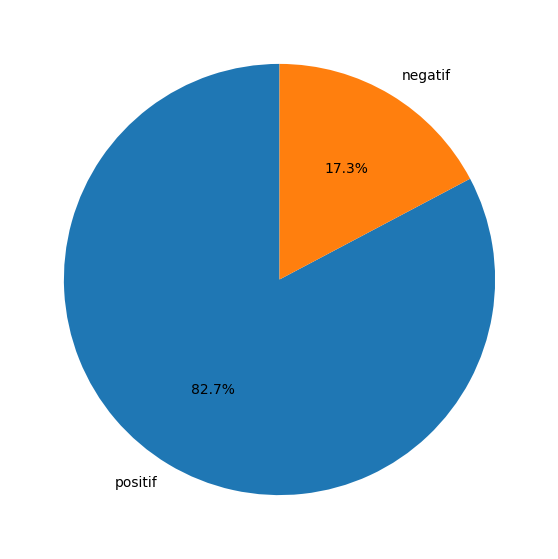

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.show()

In [ ]:
df['Review'].head()

,Review
0,tolong dong dibantu masa setiap mau upload foto gabisa terus. kesel
1,"bagus sih, tapi pas konsul 30 menit itu menurutku kurang apalagi buat ke psikolog, yang belum tentu responya cepat, jadi waktunya habis duluan sebelum chatnya selesai"
2,sering bermasalah pas pembayaran divirtual account sebelum update baik2 saja setelah update malah sering gk bs virtual accountnya
3,"app ini sangat membantu, tapi kalau ada kendala, ga ada customer service chat. harus email ataupun telepon. saat keadaan sedang sakit kita mau complain dokter dan aplikasi langsung dengan fitur chat lebih baik daripada harus telepon"
4,"Driver pengantaran obat tidak proffesional. Tidak menggunakan sepatu jadi tidak mau masuk gedung. memilih membatalkan sepihak dari kurirnya. waktu saya terbuang. sudah cukup. ini terakhir kali saya pakai aplikasi halo doc. kurir tersebut dari medex. Sudah dikirim ulang oleh go send dan memuaskan untuk go sendnya. Jangan pakai medex lagi, gunakan go send saja 100%."


**Clean Text**

In [ ]:
df['Review'] = df['Review'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', ' ', str(x))
)
df['Review'].head()

,Review
0,tolong dong dibantu masa setiap mau upload foto gabisa terus kesel
1,bagus sih tapi pas konsul menit itu menurutku kurang apalagi buat ke psikolog yang belum tentu responya cepat jadi waktunya habis duluan sebelum chatnya selesai
2,sering bermasalah pas pembayaran divirtual account sebelum update baik saja setelah update malah sering gk bs virtual accountnya
3,app ini sangat membantu tapi kalau ada kendala ga ada customer service chat harus email ataupun telepon saat keadaan sedang sakit kita mau complain dokter dan aplikasi langsung dengan fitur chat lebih baik daripada harus telepon
4,Driver pengantaran obat tidak proffesional Tidak menggunakan sepatu jadi tidak mau masuk gedung memilih membatalkan sepihak dari kurirnya waktu saya terbuang sudah cukup ini terakhir kali saya pakai aplikasi halo doc kurir tersebut dari medex Sudah dikirim ulang oleh go send dan memuaskan untuk go sendnya Jangan pakai medex lagi gunakan go send saja


**Case** **Folding**

In [ ]:
df['Review'] = df['Review'].str.lower()
df['Review'].head()

,Review
0,tolong dong dibantu masa setiap mau upload foto gabisa terus kesel
1,bagus sih tapi pas konsul menit itu menurutku kurang apalagi buat ke psikolog yang belum tentu responya cepat jadi waktunya habis duluan sebelum chatnya selesai
2,sering bermasalah pas pembayaran divirtual account sebelum update baik saja setelah update malah sering gk bs virtual accountnya
3,app ini sangat membantu tapi kalau ada kendala ga ada customer service chat harus email ataupun telepon saat keadaan sedang sakit kita mau complain dokter dan aplikasi langsung dengan fitur chat lebih baik daripada harus telepon
4,driver pengantaran obat tidak proffesional tidak menggunakan sepatu jadi tidak mau masuk gedung memilih membatalkan sepihak dari kurirnya waktu saya terbuang sudah cukup ini terakhir kali saya pakai aplikasi halo doc kurir tersebut dari medex sudah dikirim ulang oleh go send dan memuaskan untuk go sendnya jangan pakai medex lagi gunakan go send saja


**Tokenization**

In [ ]:
df['Review'] = df['Review'].apply(word_tokenize)
df['Review'].head()

,Review
0,"[tolong, dong, dibantu, masa, setiap, mau, upload, foto, gabisa, terus, kesel]"
1,"[bagus, sih, tapi, pas, konsul, menit, itu, menurutku, kurang, apalagi, buat, ke, psikolog, yang, belum, tentu, responya, cepat, jadi, waktunya, habis, duluan, sebelum, chatnya, selesai]"
2,"[sering, bermasalah, pas, pembayaran, divirtual, account, sebelum, update, baik, saja, setelah, update, malah, sering, gk, bs, virtual, accountnya]"
3,"[app, ini, sangat, membantu, tapi, kalau, ada, kendala, ga, ada, customer, service, chat, harus, email, ataupun, telepon, saat, keadaan, sedang, sakit, kita, mau, complain, dokter, dan, aplikasi, langsung, dengan, fitur, chat, lebih, baik, daripada, harus, telepon]"
4,"[driver, pengantaran, obat, tidak, proffesional, tidak, menggunakan, sepatu, jadi, tidak, mau, masuk, gedung, memilih, membatalkan, sepihak, dari, kurirnya, waktu, saya, terbuang, sudah, cukup, ini, terakhir, kali, saya, pakai, aplikasi, halo, doc, kurir, tersebut, dari, medex, sudah, dikirim, ulang, oleh, go, send, dan, memuaskan, untuk, go, sendnya, jangan, pakai, medex, lagi, gunakan, go, send, saja]"


**Stop Word Removal**

In [ ]:
stop_words = set(stopwords.words('indonesian'))

df['Review'] = df['Review'].apply(
    lambda x: [word for word in x if word not in stop_words]
)
df['Review'].head()

,Review
0,"[tolong, dibantu, upload, foto, gabisa, kesel]"
1,"[bagus, sih, pas, konsul, menit, menurutku, psikolog, responya, cepat, habis, duluan, chatnya, selesai]"
2,"[bermasalah, pas, pembayaran, divirtual, account, update, update, gk, bs, virtual, accountnya]"
3,"[app, membantu, kendala, ga, customer, service, chat, email, telepon, sakit, complain, dokter, aplikasi, langsung, fitur, chat, telepon]"
4,"[driver, pengantaran, obat, proffesional, sepatu, masuk, gedung, memilih, membatalkan, kurirnya, terbuang, kali, pakai, aplikasi, halo, doc, kurir, medex, dikirim, ulang, go, send, memuaskan, go, sendnya, pakai, medex, go, send]"


**Stemming**

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['Review'] = df['Review'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)
df['Review'].head()

,Review
0,"[tolong, bantu, upload, foto, gabisa, kesel]"
1,"[bagus, sih, pas, konsul, menit, turut, psikolog, responya, cepat, habis, duluan, chatnya, selesai]"
2,"[masalah, pas, bayar, virtual, account, update, update, gk, bs, virtual, accountnya]"
3,"[app, bantu, kendala, ga, customer, service, chat, email, telepon, sakit, complain, dokter, aplikasi, langsung, fitur, chat, telepon]"
4,"[driver, antar, obat, proffesional, sepatu, masuk, gedung, pilih, batal, kurir, buang, kali, pakai, aplikasi, halo, doc, kurir, medex, kirim, ulang, go, send, muas, go, sendnya, pakai, medex, go, send]"


**Detokenize**

In [ ]:
df['Review'] = df['Review'].apply(lambda x: ' '.join(x))
df['Review'].head()

,Review
0,tolong bantu upload foto gabisa kesel
1,bagus sih pas konsul menit turut psikolog responya cepat habis duluan chatnya selesai
2,masalah pas bayar virtual account update update gk bs virtual accountnya
3,app bantu kendala ga customer service chat email telepon sakit complain dokter aplikasi langsung fitur chat telepon
4,driver antar obat proffesional sepatu masuk gedung pilih batal kurir buang kali pakai aplikasi halo doc kurir medex kirim ulang go send muas go sendnya pakai medex go send


**Split Data**

In [ ]:
X = df['Review']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print('Data Training:', len(X_train))
print('Data Testing:', len(X_test))

Data Training: 1172
Data Testing: 294


In [ ]:
print('Training:')
print(y_train.value_counts())

print('\nTesting:')
print(y_test.value_counts())

Training:
Sentiment
positif    970
negatif    202
Name: count, dtype: int64

Testing:
Sentiment
positif    243
negatif     51
Name: count, dtype: int64


# TD-IDF

In [ ]:
#TF-IDF
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
vocab = tfidf_vectorizer.get_feature_names_out()

tfidf_sample = pd.DataFrame({
    'Kata': vocab,
    'Bobot TF-IDF': X_train_tfidf[0].toarray().flatten()
})

tfidf_sample = tfidf_sample[tfidf_sample['Bobot TF-IDF'] > 0.0].head(10)

tfidf_sample

,Kata,Bobot TF-IDF
128,bantu,0.223306
198,bru,0.721131
933,moga,0.453100
1068,pakai,0.474136


In [ ]:
print("Ukuran X_train_tfidf:", X_train_tfidf.shape)
print("Ukuran X_test_tfidf:", X_test_tfidf.shape)

Ukuran X_train_tfidf: (1172, 1594)
Ukuran X_test_tfidf: (294, 1594)


# SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

In [ ]:
print('Sebelum SMOTE:')
print(y_train.value_counts())

print('\nSetelah SMOTE:')
print(y_train_smote.value_counts())

Sebelum SMOTE:
Sentiment
positif    970
negatif    202
Name: count, dtype: int64

Setelah SMOTE:
Sentiment
positif    970
negatif    970
Name: count, dtype: int64


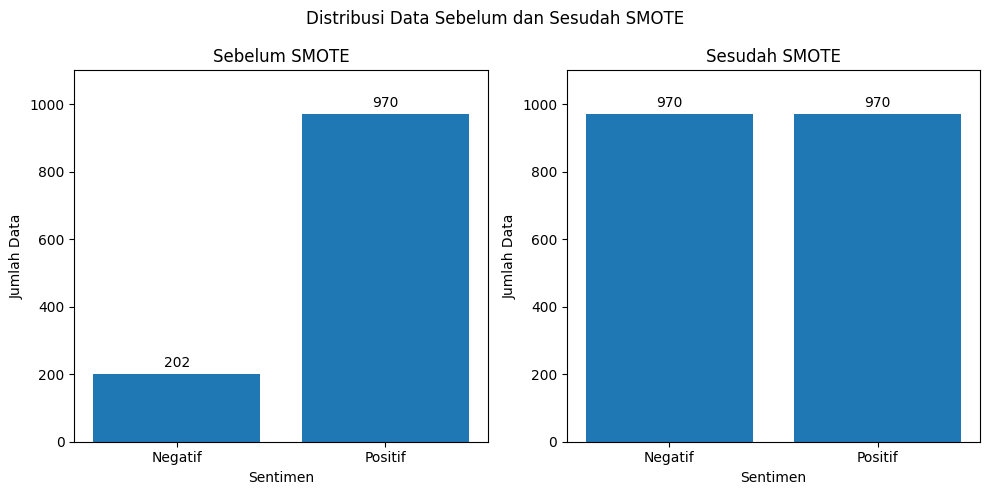

In [ ]:
import matplotlib.pyplot as plt

labels = ['Negatif', 'Positif']

before = [202, 970]
after = [970, 970]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bars1 = axes[0].bar(labels, before)
axes[0].set_title('Sebelum SMOTE')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, 1100)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha='center'
    )

bars2 = axes[1].bar(labels, after)
axes[1].set_title('Sesudah SMOTE')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah Data')
axes[1].set_ylim(0, 1100)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(int(bar.get_height())),
        ha='center'
    )

plt.suptitle('Distribusi Data Sebelum dan Sesudah SMOTE')
plt.tight_layout()
plt.show()

# Implementasi

**Naive Bayes**

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_smote, y_train_smote)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [ ]:
y_pred_nb[:10]

array(['positif', 'positif', 'positif', 'negatif', 'negatif', 'positif',
       'positif', 'positif', 'positif', 'positif'], dtype='<U7')

**Logistic** **regression**

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [ ]:
y_pred_lr[:10]

array(['positif', 'positif', 'positif', 'negatif', 'negatif', 'positif',
       'positif', 'positif', 'positif', 'positif'], dtype=object)

# Evaluasi

**Naive** **Bayes**

In [ ]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, pos_label='positif')
recall_nb = recall_score(y_test, y_pred_nb, pos_label='positif')
f1_nb = f1_score(y_test, y_pred_nb, pos_label='positif')

print('Naive Bayes')
print('Accuracy :', accuracy_nb)
print('Precision:', precision_nb)
print('Recall   :', recall_nb)
print('F1-Score :', f1_nb)

Naive Bayes
Accuracy : 0.8945578231292517
Precision: 0.9907407407407407
Recall   : 0.8806584362139918
F1-Score : 0.9324618736383442


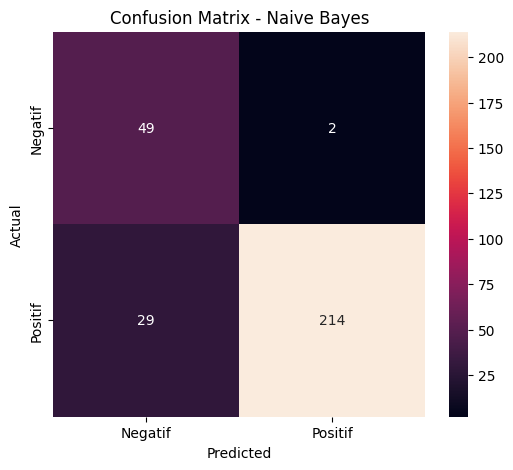

In [ ]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=['negatif', 'positif']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['Negatif', 'Positif'],
    yticklabels=['Negatif', 'Positif']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

**Logistic Regression**

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label='positif')
recall_lr = recall_score(y_test, y_pred_lr, pos_label='positif')
f1_lr = f1_score(y_test, y_pred_lr, pos_label='positif')

print('Logistic Regression')
print('Accuracy :', accuracy_lr)
print('Precision:', precision_lr)
print('Recall   :', recall_lr)
print('F1-Score :', f1_lr)

Logistic Regression
Accuracy : 0.9421768707482994
Precision: 0.9708333333333333
Recall   : 0.9588477366255144
F1-Score : 0.9648033126293996


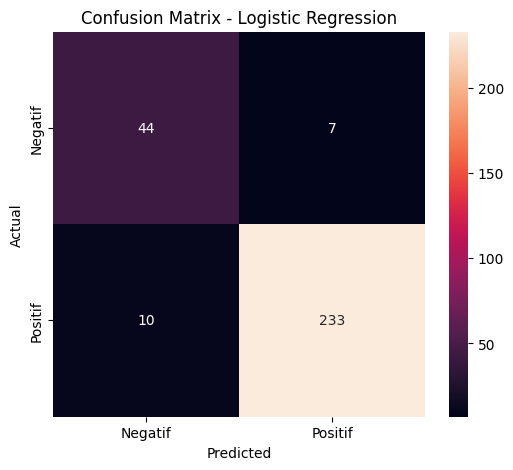

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=['negatif', 'positif']
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['Negatif', 'Positif'],
    yticklabels=['Negatif', 'Positif']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# Perbandingan Kinerja

In [ ]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_nb, accuracy_lr],
    'Precision': [precision_nb, precision_lr],
    'Recall': [recall_nb, recall_lr],
    'F1-Score': [f1_nb, f1_lr]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.894558,0.990741,0.880658,0.932462
1,Logistic Regression,0.942177,0.970833,0.958848,0.964803


In [ ]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [accuracy_nb, accuracy_lr],
    'Precision': [precision_nb, precision_lr],
    'Recall': [recall_nb, recall_lr],
    'F1-Score': [f1_nb, f1_lr]
})

results_percent = results.copy()

results_percent[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
] = results_percent[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
] * 100

results_percent.round(2)

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,89.46,99.07,88.07,93.25
1,Logistic Regression,94.22,97.08,95.88,96.48


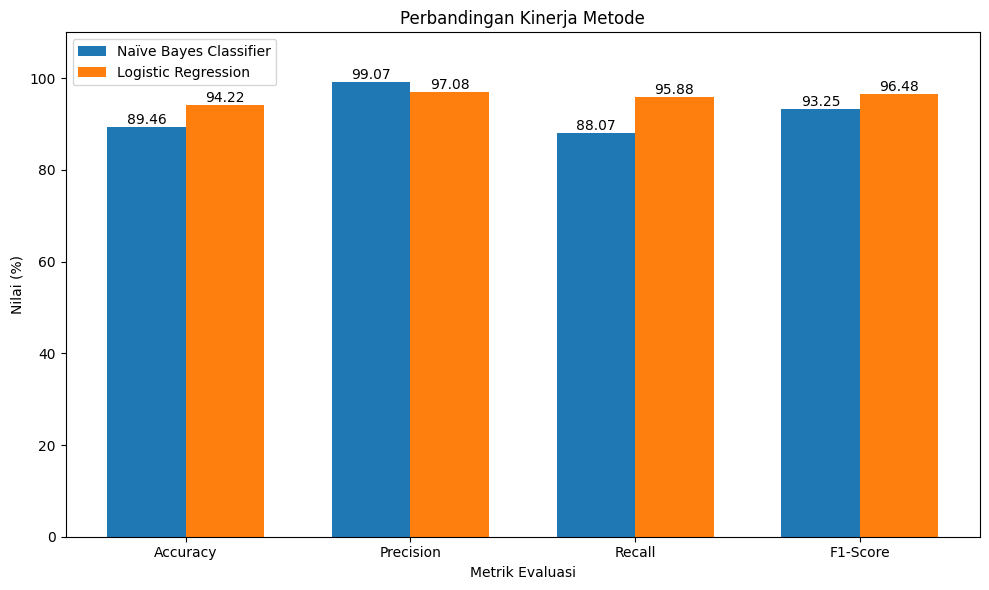

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

naive_bayes = [89.46, 99.07, 88.07, 93.25]
logistic_regression = [94.22, 97.08, 95.88, 96.48]

x = np.arange(len(metrik))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_nb = ax.bar(
    x - width/2,
    naive_bayes,
    width,
    label='Naïve Bayes Classifier'
)

bars_lr = ax.bar(
    x + width/2,
    logistic_regression,
    width,
    label='Logistic Regression'
)

ax.set_title('Perbandingan Kinerja Metode')
ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Nilai (%)')
ax.set_xticks(x)
ax.set_xticklabels(metrik)
ax.set_ylim(0, 110)

ax.bar_label(bars_nb, fmt='%.2f')
ax.bar_label(bars_lr, fmt='%.2f')

ax.legend()

plt.tight_layout()
plt.show()